# Limits: Approaching a Value

**This notebook teaches limits from scratch — it assumes only that you can evaluate a function.**

Calculus is built on one slightly strange idea: asking what a function is *heading toward* near a
point, without ever arriving. That sounds like a technicality. It isn't — it is the move that makes
derivatives possible, because a derivative is a fraction whose top and bottom both shrink to zero, and
"zero over zero" only means something as a limit.

## Learning objectives

- State informally what $\lim_{x \to a} f(x) = L$ means.
- Evaluate a limit **numerically**, approaching from both sides.
- Distinguish the limit at $a$ from the value $f(a)$.

## Background

We write

$$\lim_{x \to a} f(x) = L$$

to say: as $x$ gets arbitrarily close to $a$ — from either side, but never equal to $a$ — the value
$f(x)$ gets arbitrarily close to $L$.

Two things make this different from just plugging in $a$:

- The limit only cares about $x$ **near** $a$, never $x = a$ itself. What happens exactly at $a$ is
  irrelevant, and $f(a)$ may not even exist.
- The value has to be the same **from both sides**. Approaching from the left and from the right must
  agree, or the limit does not exist.

## This notebook covers

1. Approaching a point numerically from both sides.
2. Zooming in: what "arbitrarily close" looks like.
3. Why $\lim_{x\to a} f(x)$ and $f(a)$ are different questions.

**Prerequisites:** `U1-3_Functions-1_DomainRangeAndFamilies`

**Dataset:** none — functions are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. Walking in from both sides

Take $f(x) = x^2$ and ask what it approaches as $x \to 1$. Step in from the left ($x = 0.9, 0.99,
0.999, \dots$) and from the right ($1.1, 1.01, 1.001, \dots$) and watch both columns.

In [2]:
def f(x):
    return x**2

a = 1.0
steps = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

print(f"approaching x = {a}\n")
print(f"{'step':>10} {'x (left)':>12} {'f(x)':>12}   |{'x (right)':>12} {'f(x)':>12}")
print("-" * 68)
for h in steps:
    left, right = a - h, a + h
    print(f"{h:10.0e} {left:12.6f} {f(left):12.6f}   |{right:12.6f} {f(right):12.6f}")
print("-" * 68)
print(f"{'':>10} {'':>12} {'-> 1.000000':>12}   |{'':>12} {'<- 1.000000':>12}")

approaching x = 1.0

      step     x (left)         f(x)   |   x (right)         f(x)
--------------------------------------------------------------------
     1e-01     0.900000     0.810000   |    1.100000     1.210000
     1e-02     0.990000     0.980100   |    1.010000     1.020100
     1e-03     0.999000     0.998001   |    1.001000     1.002001
     1e-04     0.999900     0.999800   |    1.000100     1.000200
     1e-05     0.999990     0.999980   |    1.000010     1.000020
     1e-06     0.999999     0.999998   |    1.000001     1.000002
--------------------------------------------------------------------
                         -> 1.000000   |              <- 1.000000


Both columns close in on **1**. That is the entire content of $\lim_{x \to 1} x^2 = 1$: not that
$f(1) = 1$ (though here it happens to be), but that the values *converge* to 1 as you approach.

## 2. Zooming in

"Arbitrarily close" is easier to believe when you watch it. Each panel below zooms the window around
$x = 1$ by a factor of ten. The curve flattens toward the dashed target as the window shrinks — no
matter how far you zoom, the function is still heading to the same place.

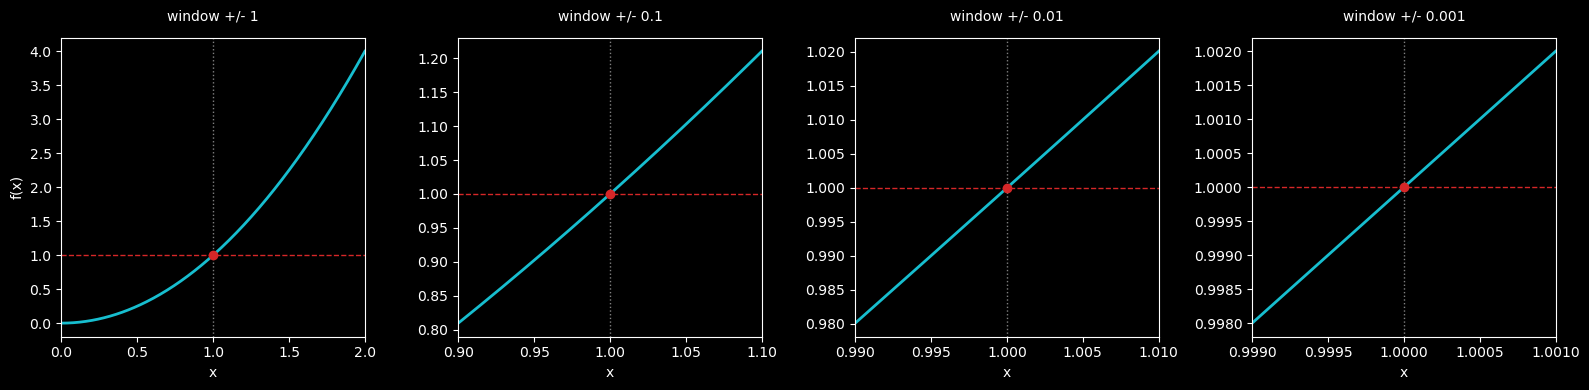

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, width in zip(axes, [1.0, 0.1, 0.01, 0.001]):
    xs = np.linspace(a - width, a + width, 400)
    ax.plot(xs, f(xs), color="tab:cyan", lw=2)
    ax.axhline(1.0, color="tab:red", ls="--", lw=1)
    ax.axvline(a, color="gray", ls=":", lw=1)
    ax.plot(a, f(a), "o", color="tab:red", markersize=6)
    ax.set_xlim(a - width, a + width)
    ax.set_title(f"window +/- {width:g}", pad=12, fontsize=10)
    ax.set_xlabel("x")
axes[0].set_ylabel("f(x)")
plt.tight_layout()
plt.show()

## 3. The limit is not the same question as the value

Here is why the distinction matters. Consider

$$g(x) = \frac{x^2 - 1}{x - 1}$$

At $x = 1$ this is $\frac{0}{0}$ — undefined. The function has **no value** there, and
evaluating it raises `ZeroDivisionError`. But the *limit* is perfectly well behaved, because for every $x \neq 1$ we can cancel:

$$\frac{x^2-1}{x-1} = \frac{(x-1)(x+1)}{x-1} = x + 1$$

and $x + 1 \to 2$. So $\lim_{x\to 1} g(x) = 2$ even though $g(1)$ does not exist.

This is exactly the situation every derivative will be in: a fraction that is $0/0$ at the point of
interest, but which has a perfectly good limit.

In [4]:
def g(x):
    return (x**2 - 1) / (x - 1)

try:
    g(1.0)
except ZeroDivisionError:
    print("g(1) directly  ->  ZeroDivisionError: the formula is 0/0 there, so there is no value\n")

print(f"{'step':>10} {'g(1 - step)':>14} {'g(1 + step)':>14}")
print("-" * 40)
for h in [1e-1, 1e-2, 1e-3, 1e-6, 1e-9]:
    print(f"{h:10.0e} {g(a - h):14.9f} {g(a + h):14.9f}")
print("-" * 40)
print(f"{'':>10} {'-> 2':>14} {'<- 2':>14}")

g(1) directly  ->  ZeroDivisionError: the formula is 0/0 there, so there is no value

      step    g(1 - step)    g(1 + step)
----------------------------------------
     1e-01    1.900000000    2.100000000
     1e-02    1.990000000    2.010000000
     1e-03    1.999000000    2.001000000
     1e-06    1.999999000    2.000001000
     1e-09    2.000000000    2.000000000
----------------------------------------
                     -> 2           <- 2


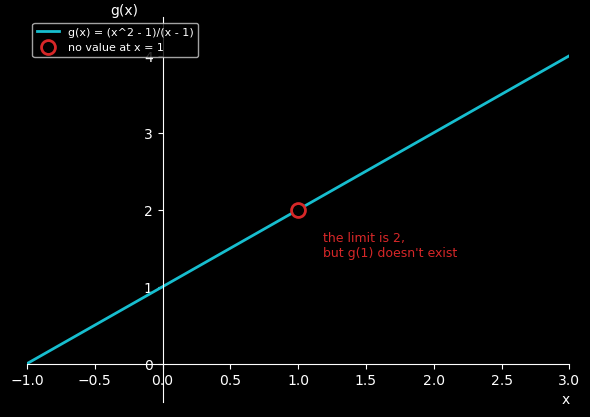

In [5]:
xs = np.linspace(-1, 3, 400)
xs = xs[np.abs(xs - 1) > 1e-9]          # skip the undefined point itself
with np.errstate(divide="ignore", invalid="ignore"):
    ys = g(xs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xs, ys, color="tab:cyan", lw=2, label="g(x) = (x^2 - 1)/(x - 1)")
# the hole: the limit exists, the value does not
ax.plot(1, 2, "o", markerfacecolor="black", markeredgecolor="tab:red",
        markeredgewidth=2, markersize=10, zorder=5, label="no value at x = 1")
ax.annotate("the limit is 2,\nbut g(1) doesn't exist", (1, 2), textcoords="offset points",
            xytext=(18, -34), color="tab:red", fontsize=9)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("g(x)", loc="top", rotation=0)
ax.set_xlim(-1, 3); ax.set_ylim(-0.5, 4.5)
ax.legend(loc="upper left", fontsize=8)
plt.show()

The open circle is the whole point. The curve *heads for* $(1, 2)$ from both directions, but there is
a puncture exactly at the destination. The limit describes the journey, not the arrival.

## 4. Summary

- $\lim_{x\to a} f(x) = L$ means $f(x)$ gets arbitrarily close to $L$ as $x$ approaches $a$ **from
  both sides**, without $x$ ever equalling $a$.
- Evaluate one numerically by stepping in from the left and right and watching both columns converge.
- **The limit and the value are different questions.** $\lim_{x\to a}f(x)$ can exist where $f(a)$ does
  not — as with $\frac{x^2-1}{x-1}$ at $x=1$, which is $0/0$ but heads for 2.
- That last case is not exotic: every derivative in §3.3 is a $0/0$ fraction rescued by a limit.

Next: what happens when the two sides *don't* agree — continuity and the ways it fails
(`U3-2_Limits-2_ContinuityAndDiscontinuity`).